# 2. UMAP + HDBSCAN

Embed the continuum removed spectra of notebook 1 with UMAP and cluster the
embedding with HDBSCAN.  Only the wavelength window around the Si II 5972 and
6355 features is handed to UMAP; the observed fluxes span some seventeen orders
of magnitude across the sample, so the continuum removed ones are used.

| input | what it provides |
| --- | --- |
| `metadata/params.csv` | one row per spectrum: the table built in notebook 0; fixes the row order |
| `data/F30_norm.csv` | one column per spectrum: the continuum removed fluxes built in notebook 1 |

| output | |
| --- | --- |
| `results/umap_5100_6450_dim2_nei12_eps0475.csv` | `params.csv` with `umap_x`, `umap_y` and `DB_label` appended.  The name records the run -- window, UMAP dimensions and neighbours, HDBSCAN epsilon -- so two settings never overwrite each other |


## Imports

In [1]:
import os
import pandas as pd

In [2]:
import hdbscan
import umap

In [3]:
import matplotlib.pyplot as plt

## Configuration


In [4]:
# Input / output locations
PARAMS_PATH = './metadata/params.csv'
SPECTRUM_TABLE_PATH = './data/F30_norm.csv'

RESULTS_DIR = './results'

# Wavelength window handed to UMAP [Angstrom].  It covers the Si II 5972 and
# 6355 features, the part of the spectrum the classification rests on, and is
# narrower than the 5000-7000 grid the spectrum table is sampled on.
WINDOW_MIN_AA = 5100
WINDOW_MAX_AA = 6450

# Column label format written by notebook 1: '<SN name>%%%<SN type>$$$<phase>'
NAME_TYPE_SEPARATOR = '%%%'

In [5]:
# UMAP.  `min_dist = 0` packs each group as tightly as UMAP allows, which is what
# HDBSCAN wants to see; `random_state` fixes the layout across runs.
UMAP_N_COMPONENTS = 2
UMAP_N_NEIGHBORS = 12
UMAP_MIN_DIST = 0.0
UMAP_METRIC = 'euclidean'
UMAP_RANDOM_STATE = 50

# HDBSCAN.  `leaf` selection keeps the small subtypes apart instead of merging
# them into their parent cluster; the epsilon then sets how close two leaves have
# to be before they are joined again.
HDBSCAN_MIN_CLUSTER_SIZE = 2
HDBSCAN_CLUSTER_SELECTION_EPSILON = 0.475
HDBSCAN_CLUSTER_SELECTION_METHOD = 'leaf'

# Columns appended to params.csv
EMBEDDING_COLUMNS = ['umap_x', 'umap_y']
LABEL_COLUMN = 'DB_label'

# HDBSCAN marks a point it leaves out of every cluster with this label
NOISE_LABEL = -1

In [6]:
# The settings above name the output.  The epsilon drops its decimal point
# (0.475 -> 0475), the convention the earlier result files were named by.
EPSILON_TAG = str(HDBSCAN_CLUSTER_SELECTION_EPSILON).replace('.', '')

RESULTS_PATH = (f'{RESULTS_DIR}/umap_{WINDOW_MIN_AA}_{WINDOW_MAX_AA}'
                f'_dim{UMAP_N_COMPONENTS}_nei{UMAP_N_NEIGHBORS}_eps{EPSILON_TAG}.csv')

RESULTS_PATH

'./results/umap_5100_6450_dim2_nei12_eps0475.csv'

## Reading the inputs


In [7]:
def load_params(params_path=PARAMS_PATH):
    """Read the metadata table built in notebook 0.

    Its row order becomes the row order of the results table.
    """
    return pd.read_csv(params_path)

In [8]:
def load_fluxes(params, spectrum_path=SPECTRUM_TABLE_PATH,
                window_min=WINDOW_MIN_AA, window_max=WINDOW_MAX_AA):
    """Read the normalized spectrum table of notebook 1 as one row per supernova.

    The table holds one column per spectrum, labelled
    `<SN name>%%%<SN type>$$$<phase>`, and one row per wavelength bin.  It is cut
    to the window given, transposed so that each supernova becomes a row and each
    wavelength a feature, and reordered to follow the rows of `params` so that the
    embedding can be written straight back next to the metadata.
    """
    spectra = pd.read_csv(spectrum_path).set_index('AA')
    spectra = spectra[(spectra.index > window_min) & (spectra.index < window_max)]

    column_of = {column.split(NAME_TYPE_SEPARATOR)[0]: column for column in spectra.columns}
    if len(column_of) != len(spectra.columns):
        raise ValueError('the spectrum table holds more than one spectrum per supernova')

    # A missing supernova raises a KeyError naming it
    ordered = spectra[[column_of[name] for name in params['SN_name']]]

    return ordered.T.reset_index(drop=True)

## Embedding and clustering


In [9]:
def embed(fluxes, n_components=UMAP_N_COMPONENTS, n_neighbors=UMAP_N_NEIGHBORS,
          min_dist=UMAP_MIN_DIST, metric=UMAP_METRIC, random_state=UMAP_RANDOM_STATE):
    """UMAP embedding of the fluxes, one row per supernova."""
    reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors,
                        min_dist=min_dist, metric=metric, random_state=random_state)

    return reducer.fit_transform(fluxes)

In [10]:
def cluster(embedding, min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
            cluster_selection_epsilon=HDBSCAN_CLUSTER_SELECTION_EPSILON,
            cluster_selection_method=HDBSCAN_CLUSTER_SELECTION_METHOD):
    """HDBSCAN label of every embedded spectrum; -1 is a spectrum left unclustered."""
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        cluster_selection_epsilon=cluster_selection_epsilon,
        cluster_selection_method=cluster_selection_method,
    ).fit(embedding)

    return clusterer.labels_

## Run


In [11]:
params = load_params()
fluxes = load_fluxes(params)
print(f'{len(fluxes)} spectra x {fluxes.shape[1]} wavelength bins '
      f'({WINDOW_MIN_AA}-{WINDOW_MAX_AA} A)')

119 spectra x 675 wavelength bins (5100-6450 A)


In [12]:
embedding = embed(fluxes)
labels = cluster(embedding)

results = params.copy()
results[EMBEDDING_COLUMNS] = embedding
results[LABEL_COLUMN] = labels

n_clusters = len(set(labels) - {NOISE_LABEL})
n_noise = int((labels == NOISE_LABEL).sum())
print(f'{n_clusters} clusters, {n_noise} spectra unclustered')
results.head()

6 clusters, 4 spectra unclustered


,SN_name,RA,DEC,redshift,host_name,Host_RA,Host_DEC,logd25,e_logd25,logr25,...,v_si_err,R_si,D15,D15_err,phase,filename_csv,Del_Lambda,umap_x,umap_y,DB_label
0,SN1994D,188.51021,7.70131,0.001494,NGC4526,188.512545,7.699261,1.842,0.018,0.449,...,0.00,0.280823,1.37,0.03,0.35,SN1994D_1994-03-21_08-24-00_FLWO-1.5m_FAST_CfA...,1.467083,9.105375,7.286631,5
1,SN1994S,187.84108,29.13450,0.015177,NGC4495,187.845363,29.136442,1.128,0.035,0.373,...,0.01,0.091101,0.94,0.06,1.00,SN_1994S_1994-06-16_00-00-00_Lick-3m_KAST_UCB-...,1.969612,8.626638,6.377733,5
2,SN1996ai,197.74221,37.05983,0.002900,NGC5005,197.734470,37.058994,1.683,0.025,0.500,...,0.01,0.183989,0.88,0.06,-0.10,SN_1996ai_1996-06-21_00-00-00_Lick-3m_KAST_UCB...,1.992704,7.219390,7.272726,3
3,SN1996C,207.70250,49.31864,0.027000,PGC049153,207.703404,49.315106,0.899,0.064,0.257,...,0.01,0.190395,0.93,0.06,1.98,1996C_1996-02-17_11-31-12_FLWO-1.5m_FAST_CfA-I...,1.430809,8.254621,7.339077,3
4,SN1996X,199.50471,-26.84592,0.008876,NGC5061,199.521255,-26.837131,1.574,0.027,0.092,...,0.01,0.213078,1.26,0.04,0.31,SN1996X_1996-04-18_07-26-24_FLWO-1.5m_FAST_CfA...,1.456511,9.064132,8.994831,2


### Check


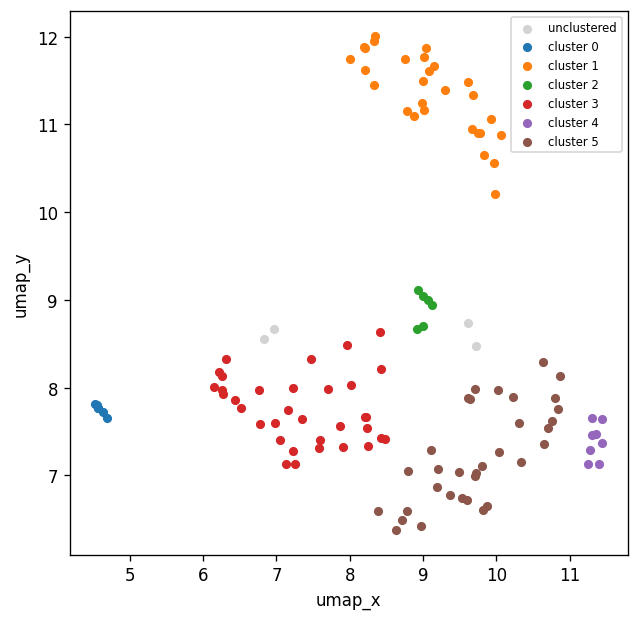

In [13]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=120)

for label in sorted(set(labels)):
    in_cluster = labels == label
    name = 'unclustered' if label == NOISE_LABEL else f'cluster {label}'
    ax.scatter(embedding[in_cluster, 0], embedding[in_cluster, 1], s=20, label=name,
               color='lightgrey' if label == NOISE_LABEL else None)

ax.set_xlabel('umap_x')
ax.set_ylabel('umap_y')
ax.legend(loc='best', fontsize=7)

plt.show()

## Write the table


In [14]:
os.makedirs(RESULTS_DIR, exist_ok=True)
results.to_csv(RESULTS_PATH, index=False)
print(f'written to {RESULTS_PATH}')

written to ./results/umap_5100_6450_dim2_nei12_eps0475.csv
